In [1]:
#importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv("diabetes_prediction_dataset.csv")

In [3]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


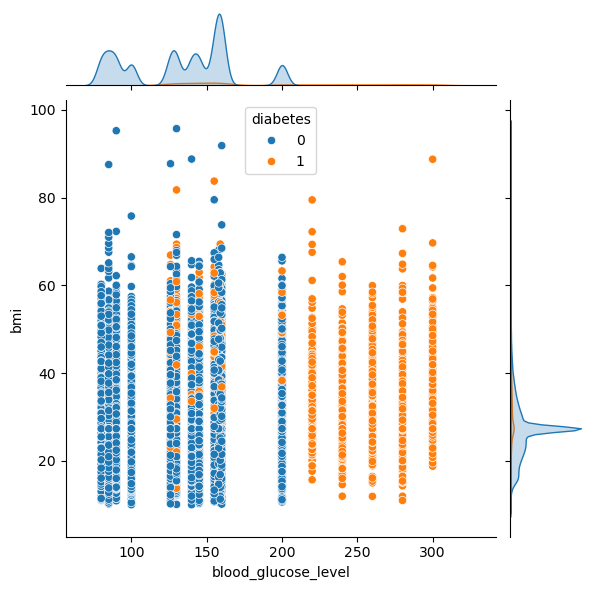

In [6]:
#EDA
sns.jointplot(data=df,x='blood_glucose_level',y='bmi',hue='diabetes')

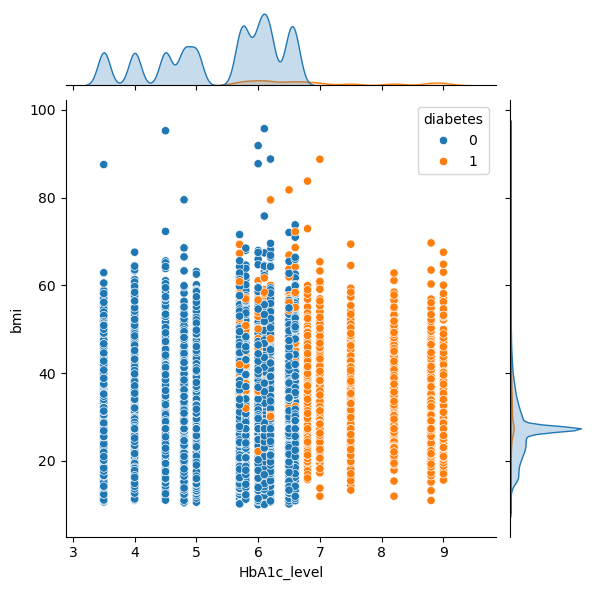

In [7]:
sns.jointplot(data=df,x='HbA1c_level',y='bmi',hue='diabetes')

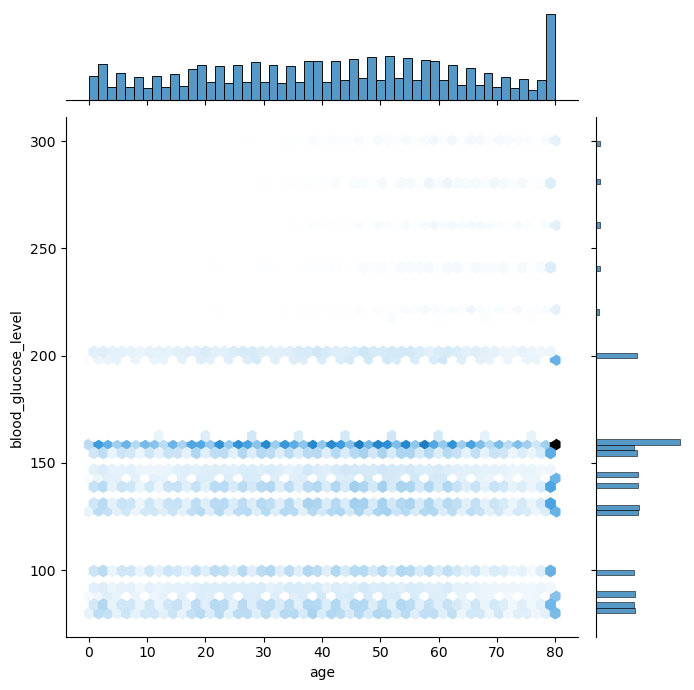

In [8]:
sns.jointplot(data=df,x="age",y="blood_glucose_level",kind="hex",height=7)

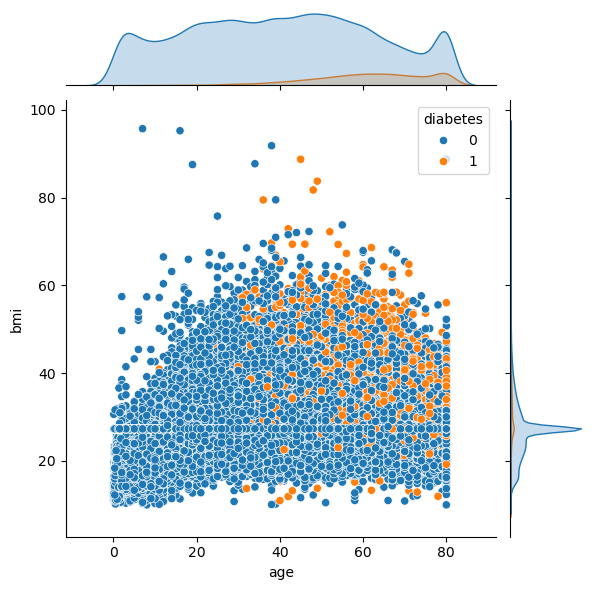

In [9]:
sns.jointplot(data=df,x='age',y='bmi',hue='diabetes')

<Axes: xlabel='smoking_history', ylabel='count'>

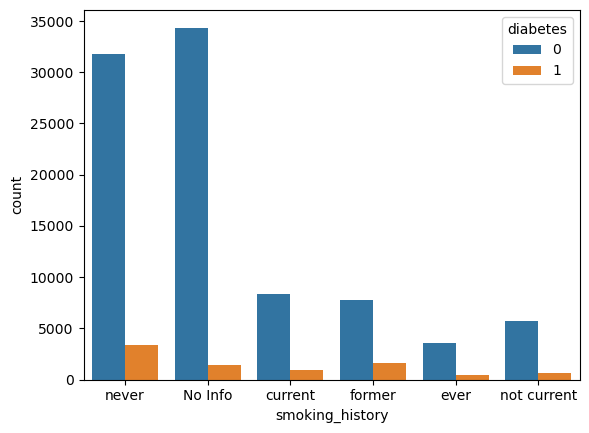

In [10]:
sns.countplot(data=df,x='smoking_history',hue='diabetes')

<Axes: xlabel='gender', ylabel='Count'>

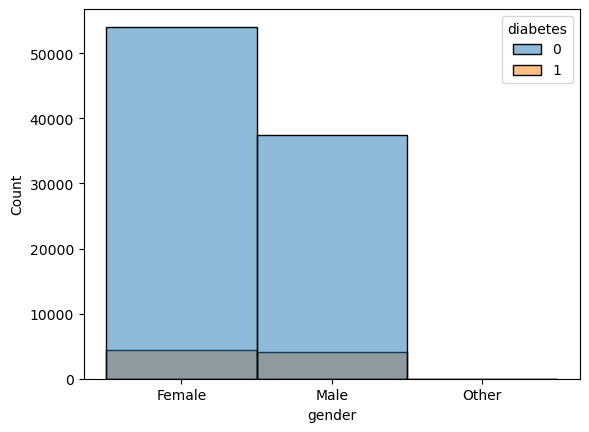

In [11]:
sns.histplot(data=df,x='gender',hue='diabetes')

In [12]:
#correlation bw num features for checking multicollinearity and how much they affect or drive diabetes
df.corr(numeric_only=True)

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
age,1.000000,0.251171,0.233354,0.337396,0.101354,0.110672,0.258008
hypertension,0.251171,1.000000,0.121262,0.147666,0.080939,0.084429,0.197823
heart_disease,0.233354,0.121262,1.000000,0.061198,0.067589,0.070066,0.171727
bmi,0.337396,0.147666,0.061198,1.000000,0.082997,0.091261,0.214357
HbA1c_level,0.101354,0.080939,0.067589,0.082997,1.000000,0.166733,0.400660
blood_glucose_level,0.110672,0.084429,0.070066,0.091261,0.166733,1.000000,0.419558
diabetes,0.258008,0.197823,0.171727,0.214357,0.400660,0.419558,1.000000


<Axes: xlabel='bmi', ylabel='Count'>

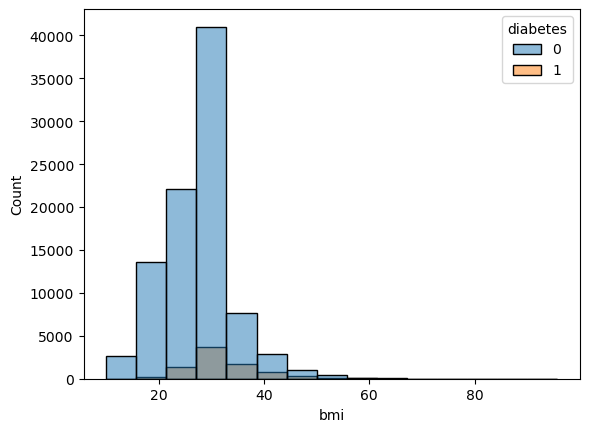

In [13]:
sns.histplot(data=df,x='bmi',hue='diabetes',bins=15)

<Axes: xlabel='bmi'>

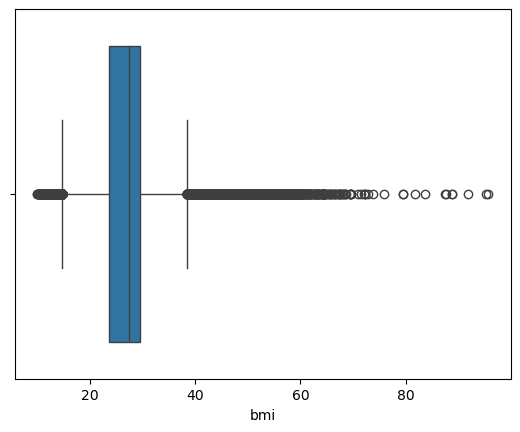

In [14]:
#Checking for outiers in bmi
sns.boxplot(data=df,x='bmi')

In [15]:
df.duplicated().sum()
df=df.drop_duplicates().reset_index(drop=True)

In [16]:
#Feature engineering
df['bmi_age']=df['bmi']*df['age']

In [17]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV

In [18]:
X=df.drop(columns=['diabetes'],axis=1)
Y=df['diabetes']

In [19]:
X_temp, X_test, Y_temp, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size=0.2, stratify=Y_temp, random_state=42)

In [20]:
import category_encoders as ce
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, make_scorer, roc_auc_score

numeric_cols = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'bmi_age']
target_enc_cols = ['smoking_history']
onehot_cols = ['gender']

preprocessor = ColumnTransformer(transformers=[('target_enc', ce.TargetEncoder(), target_enc_cols),('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),('scale', StandardScaler(), numeric_cols),])

In [21]:
#importing 4 models to test upon
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [22]:
#custom cost func, penalizing fn 5 times more than fp
def diabetes_cost_loss(Y_true,Y_pred):
    cm=confusion_matrix(Y_true,Y_pred)
    tn,fp,fn,tp=cm.ravel()
    return (5*fn)+(1*fp)

In [23]:
#wraps custom cost function into a standardized object so it can be automatically used for model tuning and cross-validation
cost_scorer = make_scorer(diabetes_cost_loss,greater_is_better=False)

In [24]:
#LOGISTIC REGRESSION
lr_pipe = Pipeline([('preprocessor', preprocessor),('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))])
lr_pipe.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('target_enc', ...), ('onehot', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
knn_pipe = Pipeline([('preprocessor', preprocessor),('model', KNeighborsClassifier(n_neighbors=12))])
knn_pipe.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('target_enc', ...), ('onehot', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [26]:
rf_pipe = Pipeline([('preprocessor', preprocessor),('model', RandomForestClassifier(class_weight='balanced', random_state=42, max_depth=5))])
rf_pipe.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('target_enc', ...), ('onehot', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [27]:
xgb_pipe = Pipeline([('preprocessor', preprocessor),('model', XGBClassifier(scale_pos_weight=10.76, random_state=42))])
xgb_pipe.fit(X_train, Y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('target_enc', ...), ('onehot', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
lr_base_preds = lr_pipe.predict(X_test)
print("\n[Baseline] Logistic Regression Report:")
print(classification_report(Y_test, lr_base_preds))
print(f"Cost: {diabetes_cost_loss(Y_test, lr_base_preds)}")


[Baseline] Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     17534
           1       0.42      0.88      0.57      1696

    accuracy                           0.88     19230
   macro avg       0.71      0.88      0.75     19230
weighted avg       0.94      0.88      0.90     19230

Cost: 3071


In [32]:
knn_base_preds = knn_pipe.predict(X_test)
print("\n[Baseline] KNN Report:")
print(classification_report(Y_test, knn_base_preds))
print(f"Cost: {diabetes_cost_loss(Y_test, knn_base_preds)}")


[Baseline] KNN Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     17534
           1       0.95      0.60      0.74      1696

    accuracy                           0.96     19230
   macro avg       0.96      0.80      0.86     19230
weighted avg       0.96      0.96      0.96     19230

Cost: 3438


In [33]:
rf_base_preds = rf_pipe.predict(X_test)
print("\n[Baseline] Random Forest Report:")
print(classification_report(Y_test, rf_base_preds))
print(f"Cost: {diabetes_cost_loss(Y_test, rf_base_preds)}")


[Baseline] Random Forest Report:
              precision    recall  f1-score   support

           0       0.99      0.87      0.93     17534
           1       0.41      0.92      0.57      1696

    accuracy                           0.88     19230
   macro avg       0.70      0.90      0.75     19230
weighted avg       0.94      0.88      0.90     19230

Cost: 2858


In [34]:
xgb_base_preds = xgb_pipe.predict(X_test)
print("\n[Baseline] XGBoost Report:")
print(classification_report(Y_test, xgb_base_preds))
print(f"Cost: {diabetes_cost_loss(Y_test, xgb_base_preds)}")


[Baseline] XGBoost Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     17534
           1       0.52      0.87      0.65      1696

    accuracy                           0.92     19230
   macro avg       0.75      0.90      0.80     19230
weighted avg       0.95      0.92      0.93     19230

Cost: 2457


In [35]:
param_dist_rf = {'model__n_estimators': [50, 100, 200],'model__max_depth': [3, 4, 5, 6, 10, 14, None],'model__min_samples_leaf': [1, 2, 4, 6, 8],}

In [36]:
param_dist_xgb = {'model__n_estimators': [50, 100, 200, 300],'model__max_depth': [3, 4, 5, 7, 9],'model__subsample': [0.8, 0.9],'model__colsample_bytree': [0.8, 0.9],'model__scale_pos_weight': [1, 5, 8, 10.76, 15, 20],}

In [37]:
print("Starting Hyperparameter Tuning for Random Forest...")
rf_search = RandomizedSearchCV(
    estimator=Pipeline([('preprocessor', preprocessor), ('model', RandomForestClassifier(random_state=42))]),
    param_distributions=param_dist_rf, n_iter=10, scoring=cost_scorer, cv=5, random_state=42, n_jobs=-1,
)

Starting Hyperparameter Tuning for Random Forest...


In [40]:
rf_search.fit(X_train,Y_train)
best_rf = rf_search.best_estimator_

In [41]:
print("Starting Hyperparameter Tuning for XGBoost...")
xgb_search = RandomizedSearchCV(
    estimator=Pipeline([('preprocessor', preprocessor), ('model', XGBClassifier(random_state=42, eval_metric='logloss'))]),
    param_distributions=param_dist_xgb, n_iter=10, scoring=cost_scorer, cv=5, random_state=42, n_jobs=-1,
)

Starting Hyperparameter Tuning for XGBoost...


In [43]:
xgb_search.fit(X_train, Y_train)
best_xgb = xgb_search.best_estimator_

In [44]:
def optimize_threshold(model, X, y_true):
    y_probs = model.predict_proba(X)[:, 1]
    _, _, thresholds = precision_recall_curve(y_true, y_probs)
    best_t, lowest_cost = 0.5, float('inf')
    for t in thresholds:
        y_pred_t = (y_probs >= t).astype(int)
        cost = diabetes_cost_loss(y_true, y_pred_t)
        if cost < lowest_cost:
            lowest_cost, best_t = cost, t
    return best_t, y_probs

In [45]:
rf_opt_threshold, _ = optimize_threshold(best_rf, X_val, Y_val)
xgb_opt_threshold, _ = optimize_threshold(best_xgb, X_val, Y_val)

In [46]:
rf_test_probs = best_rf.predict_proba(X_test)[:, 1]
xgb_test_probs = best_xgb.predict_proba(X_test)[:, 1]

In [48]:
rf_final_preds = (rf_test_probs >= rf_opt_threshold).astype(int)
xgb_final_preds = (xgb_test_probs >= xgb_opt_threshold).astype(int)

In [49]:
print(f"\n[FINAL] Tuned Random Forest (Threshold: {rf_opt_threshold:.4f}):")
print(classification_report(Y_test, rf_final_preds))
rf_final_cost = diabetes_cost_loss(Y_test, rf_final_preds)
print(f"Total Custom Penalty Cost: {rf_final_cost}")


[FINAL] Tuned Random Forest (Threshold: 0.1853):
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     17534
           1       0.63      0.81      0.71      1696

    accuracy                           0.94     19230
   macro avg       0.81      0.88      0.84     19230
weighted avg       0.95      0.94      0.94     19230

Total Custom Penalty Cost: 2414


In [50]:
print(f"\n[FINAL] Tuned XGBoost (Threshold: {xgb_opt_threshold:.4f}):")
print(classification_report(Y_test, xgb_final_preds))
xgb_final_cost = diabetes_cost_loss(Y_test, xgb_final_preds)
print(f"Total Custom Penalty Cost: {xgb_final_cost}")


[FINAL] Tuned XGBoost (Threshold: 0.5878):
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     17534
           1       0.61      0.85      0.71      1696

    accuracy                           0.94     19230
   macro avg       0.80      0.90      0.84     19230
weighted avg       0.95      0.94      0.94     19230

Total Custom Penalty Cost: 2199


In [51]:
from sklearn.metrics import roc_auc_score

In [53]:
lr_base_probs  = lr_pipe.predict_proba(X_test)[:, 1]
knn_base_probs = knn_pipe.predict_proba(X_test)[:, 1]
rf_base_probs  = rf_pipe.predict_proba(X_test)[:, 1]
xgb_base_probs = xgb_pipe.predict_proba(X_test)[:, 1]

In [54]:
print(f"Logistic Regression (Base) ROC-AUC : {roc_auc_score(Y_test, lr_base_probs):.4f}")
print(f"KNN (Base) ROC-AUC                 : {roc_auc_score(Y_test, knn_base_probs):.4f}")
print(f"Random Forest (Base) ROC-AUC       : {roc_auc_score(Y_test, rf_base_probs):.4f}")
print(f"XGBoost (Base) ROC-AUC             : {roc_auc_score(Y_test, xgb_base_probs):.4f}")

Logistic Regression (Base) ROC-AUC : 0.9601
KNN (Base) ROC-AUC                 : 0.9358
Random Forest (Base) ROC-AUC       : 0.9697
XGBoost (Base) ROC-AUC             : 0.9741


In [56]:
print(f"OPTIMIZED Random Forest ROC-AUC    : {roc_auc_score(Y_test, rf_test_probs):.4f}")
print(f"OPTIMIZED XGBoost ROC-AUC          : {roc_auc_score(Y_test, xgb_test_probs):.4f}")

OPTIMIZED Random Forest ROC-AUC    : 0.9670
OPTIMIZED XGBoost ROC-AUC          : 0.9768


In [58]:
feature_names = best_xgb.named_steps['preprocessor'].get_feature_names_out()
xgb_model = best_xgb.named_steps['model']

In [60]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=False)
print(importances)

scale__HbA1c_level             0.406853
scale__blood_glucose_level     0.322161
scale__bmi_age                 0.095415
scale__hypertension            0.061543
scale__heart_disease           0.031597
onehot__gender_Female          0.023111
target_enc__smoking_history    0.019590
onehot__gender_Male            0.015001
scale__bmi                     0.013052
scale__age                     0.011677
onehot__gender_Other           0.000000
dtype: float32


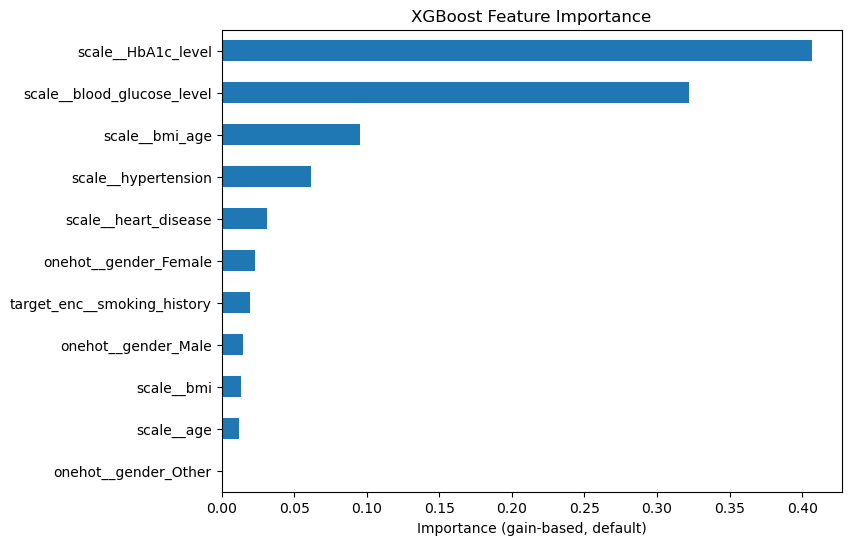

In [62]:
importances.plot(kind='barh', figsize=(8,6))
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance (gain-based, default)")
plt.show()

In [63]:
import shap

In [64]:
X_test_transformed = best_xgb.named_steps['preprocessor'].transform(X_test)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=feature_names)

In [65]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed)

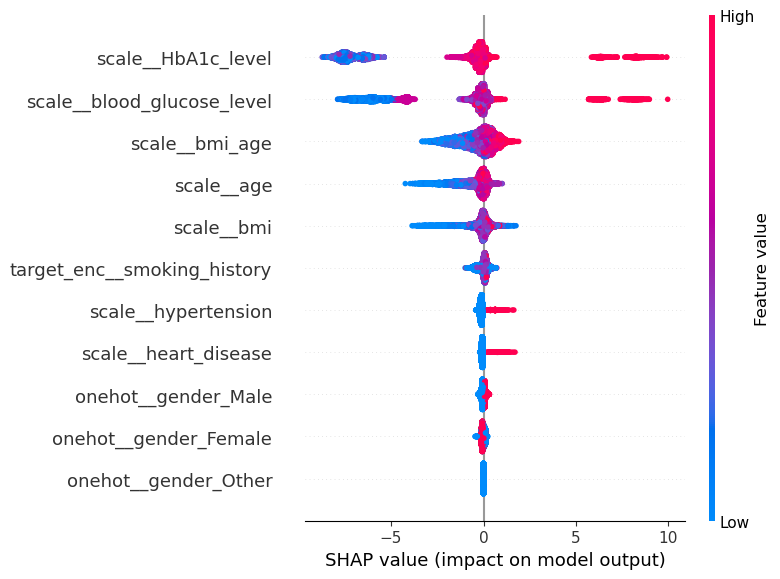

In [66]:
shap.summary_plot(shap_values, X_test_transformed)

In [70]:
from sklearn.model_selection import StratifiedKFold

def cv_cost_and_auc(model_params, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    costs, aucs, thresholds = [], [], []
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        fold_pipe = Pipeline([('preprocessor', preprocessor), ('model', XGBClassifier(**model_params))])
        fold_pipe.fit(X_tr, y_tr)

        thresh, probs = optimize_threshold(fold_pipe, X_val_fold, y_val_fold)
        preds = (probs >= thresh).astype(int)

        costs.append(diabetes_cost_loss(y_val_fold, preds))
        aucs.append(roc_auc_score(y_val_fold, probs))
        thresholds.append(thresh)
        print(f"Fold {fold+1}: cost={costs[-1]}, AUC={aucs[-1]:.4f}, threshold={thresh:.4f}")

    print(f"\nMean cost: {np.mean(costs):.1f} ± {np.std(costs):.1f}")
    print(f"Mean AUC:  {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
    return costs, aucs, thresholds

xgb_cv_costs, xgb_cv_aucs, xgb_cv_thresholds = cv_cost_and_auc(xgb_model.get_params(), X, Y, n_splits=5)

Fold 1: cost=2119, AUC=0.9783, threshold=0.6059
Fold 2: cost=2060, AUC=0.9787, threshold=0.5880
Fold 3: cost=2052, AUC=0.9805, threshold=0.5635
Fold 4: cost=2196, AUC=0.9766, threshold=0.6253
Fold 5: cost=2175, AUC=0.9773, threshold=0.6451

Mean cost: 2120.4 ± 58.4
Mean AUC:  0.9783 ± 0.0013


In [71]:
import joblib
joblib.dump(best_xgb, "diabetes_xgb_pipeline.joblib")

['diabetes_xgb_pipeline.joblib']